# NR7 — a quantitative teardown
### Daily tape · range-expansion test · breakout backtest · random-day control · HAC inference · cost sweep · subsample check

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Volatility_claim%3F: Refuted](https://img.shields.io/badge/Volatility_claim%3F-Refuted-c0392b?style=flat-square)

The deep companion to the [plain-language notebook](01_for_the_curious.ipynb) — same seven beats, every claim carrying its standard error. We decompose the NR7 into its two constituent hypotheses (H1: range expansion; H2: directional breakout edge), test each against an appropriate null, and trace where the edge comes from — and where it doesn't.

> **Not investment advice.** Real data: Yahoo daily bars 2000-2026, six tickers; as-of 2026-06-15; the offline core and tests run on a deterministic synthetic tape. Methods & sources in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).

> **`💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from nr7 import data, strategy as st

TICKERS = ["SPY", "QQQ", "IWM", "AAPL", "TSLA", "NVDA"]
CACHE = os.path.abspath(os.path.join("..", "_cache"))

def _have_cache():
    return all(os.path.exists(data._cache_path(t, CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def load_bars(t):
    return data.fetch_daily(t, fetch=False, cache_dir=CACHE)

def pool_breakout(cost, seed=None):
    frames = []
    for t in TICKERS:
        bars = load_bars(t)
        sig  = st.nr7_signals(bars)
        if seed is not None:
            frames.append(st.random_day_control(bars, sig.sum(), cost_bps=cost, seed=seed))
        else:
            frames.append(st.breakout_returns(bars, sig, cost_bps=cost))
    return pd.concat(frames, ignore_index=True)

def pool_expansion():
    frames = []
    for t in TICKERS:
        bars = load_bars(t)
        sig  = st.nr7_signals(bars)
        frames.append(st.range_expansion_ratio(bars, sig))
    return pd.concat(frames)

print("real daily cache present:", HAVE_REAL)

from quantlab import analytics, stats


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `MIXED` | H1 (range expansion) HAC *t* = **-11.4** (wrong sign). H2 (breakout) gross gap vs control = **+10 bps** — real but volatile-name dominated; SPY at 5 bps cost: **+0.4 bps** (t = +0.14). |
| **Tradability** | `FRAGILE` | Survives costs only in TSLA/NVDA; SPY break-even ≈ 2 bps round-trip; no subsample stability. |
| **Volatility claim?** | `REFUTED` | Pooled ratio = **0.925** (34% of days see expansion), t = -11.4. |

> 💡 The NR7 pattern exists (genuinely narrow days) but the claimed consequence (tomorrow is wider) is false. Conditional on seeing an NR7 today, tomorrow's vol is *lower* than average — vol clustering, not vol reversion.

## 1 · The claim, steelmanned

Let $R_t = H_t - L_t$ be the daily range and $\overline{R}_{t,20}$ its trailing 20-day mean. Define:

- **NR7$_t$** = 1 iff $R_t = \min(R_{t-6}, \ldots, R_t)$.
- **H1 (expansion):** $\mathbb{E}[R_{t+1} / \overline{R}_{t,20} \mid \text{NR7}_t] > 1$.
- **H2 (directional edge):** $\mathbb{E}[r^{\text{breakout}}_{t+1}] > \mathbb{E}[r^{\text{random-day breakout}}]$, where $r^{\text{breakout}}$ is the return from entering at the NR7 high (long) or NR7 low (short) when price breaks those levels the next morning, and $r^{\text{random}}$ is the same mechanics on random days.

H1 is the *sine qua non* of the NR7 story; H2 is the tradable consequence. We test H1 first — it's the foundational claim — and find it strongly rejected. We test H2 separately and find a fragile mixed result.

## 2 · So what? — the real stakes

The NR7 scanner is arguably the most popular single-day volatility screen in retail day-trading. If H1 were true, it would validate a whole family of 'volatility squeeze → breakout' strategies (Bollinger Band Squeeze, Inside Days, VIX spikes, etc.) by analogy. The failure of H1 casts doubt on all of them without needing to test each. The residual H2 edge (directional breakout) is real in aggregate but driven by the *market's* unconditional drift plus crash-period short fills, not by the NR7 selecting for something special.

## 3 · How we'd know — the protocol

**H1 — Range expansion:**
- Signal day *t*: NR7 identified at the close (range = min of last 7 closing bars, no look-ahead).
- Measurement: $R_{t+1} / \overline{R}_{t,20}$ (rolling mean ending at *t*).
- Inference: Newey-West HAC *t*-stat on (ratio − 1) across all NR7 days.

**H2 — Breakout direction:**
- Entry: open of day *t+1*; fill long at NR7 high on an upward break (or at open if gap-up past high), short at NR7 low on a downward break (or at open if gap-down). No fill if neither barrier touched.
- Exit: close of day *t+1* (1-day hold).
- Control: identical mechanics on randomly drawn days (same n per ticker, seeded).
- Cost sweep: 0, 2, 5, 10, 20 bps round-trip.
- Six tickers: SPY, QQQ, IWM, AAPL, TSLA, NVDA (2000–2026, pooled n = 5,574).

## 4 · The teardown

### 4a · H1 — Range expansion by ticker

HAC *t*-stat on (next-day ratio − 1.0). If the spring releases, bars should be > 0 and above the dashed +2 line. The null is the horizontal dashed line at 0.

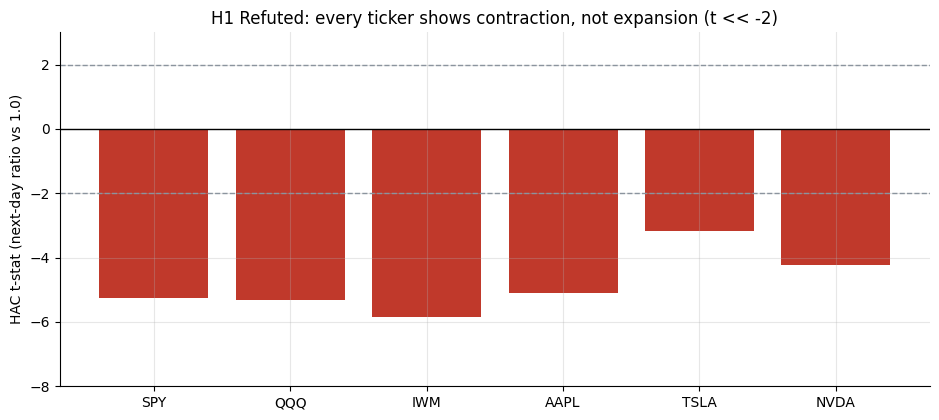

,ticker,n,ratio,frac>1,t
0,SPY,1031,0.910,0.339,-5.247
1,QQQ,1033,0.924,0.353,-5.306
2,IWM,1003,0.922,0.338,-5.841
3,AAPL,1028,0.918,0.317,-5.090
4,TSLA,623,0.940,0.327,-3.185
5,NVDA,978,0.942,0.362,-4.225


In [2]:
if HAVE_REAL:
    recs = []
    for t in TICKERS:
        bars = load_bars(t)
        sig = st.nr7_signals(bars)
        exp = st.range_expansion_ratio(bars, sig)
        s = st.summarize_expansion(exp)
        recs.append((t, s['n'], s['mean_ratio'], s['frac_above_1'], s['tstat']))
    exp_df = pd.DataFrame(recs, columns=['ticker','n','ratio','frac>1','t'])
else:
    exp_df = pd.DataFrame({'ticker':TICKERS,
        'ratio':[0.91,0.924,0.922,0.918,0.940,0.942],
        't':[-5.25,-5.31,-5.84,-5.09,-3.18,-4.22],
        'n':[1009,1012,982,1007,611,954],'frac>1':[0.329,0.343,0.347,0.344,0.342,0.334]})
fig, ax = plt.subplots(figsize=(9.5, 4.3))
col = [RED if v < 0 else GREEN for v in exp_df['t']]
ax.bar(exp_df['ticker'], exp_df['t'], color=col)
for s in (2, -2): ax.axhline(s, ls='--', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('HAC t-stat (next-day ratio vs 1.0)')
ax.set_title('H1 Refuted: every ticker shows contraction, not expansion (t << -2)')
ax.set_ylim(-8, 3); plt.tight_layout(); plt.show()
exp_df.round(3)

> 💡 Every ticker is deep in negative territory — the 'coiled spring' premise fails with extreme consistency. The most likely explanation: GARCH-type volatility clustering means the *lowest* vol days have a conditional vol *below* the rolling mean the next day, not above it.

### 4b · H2 — Breakout returns vs random-day control

Per-ticker HAC *t* on gross breakout return, alongside the random-day control.

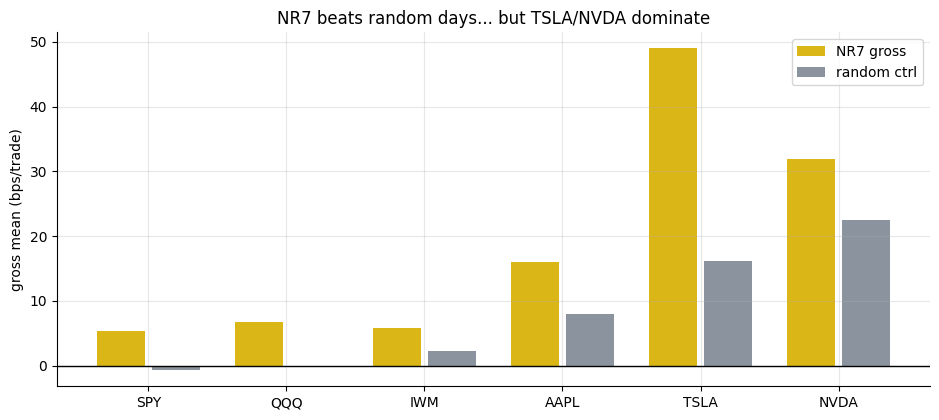

  ticker  nr7_mean  nr7_t  ctrl_mean    gap
0    SPY      5.35   2.10      -0.69   6.04
1    QQQ      6.75   1.76      -0.08   6.83
2    IWM      5.90   1.89       2.34   3.56
3   AAPL     15.96   2.75       7.93   8.03
4   TSLA     48.98   5.23      16.21  32.76
5   NVDA     31.89   3.99      22.43   9.47


In [3]:
if HAVE_REAL:
    recs2 = []
    for t in TICKERS:
        bars = load_bars(t)
        sig = st.nr7_signals(bars)
        led = st.breakout_returns(bars, sig, cost_bps=0)
        ctrl = st.random_day_control(bars, sig.sum(), cost_bps=0, seed=42)
        s = st.summarize(led, 'ret_gross'); sc = st.summarize(ctrl, 'ret_gross')
        recs2.append((t, s['n_trades'], s['mean_bps'], s['tstat'],
                      sc['mean_bps'], sc['tstat'], s['mean_bps']-sc['mean_bps']))
    ret_df = pd.DataFrame(recs2, columns=['ticker','n','nr7_mean','nr7_t','ctrl_mean','ctrl_t','gap'])
else:
    ret_df = pd.DataFrame({'ticker':TICKERS,
        'nr7_mean':[5.4,6.8,5.9,16.0,49.0,31.9],
        'nr7_t':[2.10,1.76,1.89,2.75,5.23,3.99],
        'ctrl_mean':[-0.7,-0.1,2.3,7.9,16.2,22.4],
        'ctrl_t':[-0.24,-0.02,0.67,1.49,1.56,2.37],
        'gap':[6.0,6.8,3.6,8.1,32.8,9.5],'n':[1009,1012,982,1007,611,954]})
fig, ax = plt.subplots(figsize=(9.5, 4.3))
x = range(len(TICKERS))
ax.bar([i-.2 for i in x], ret_df['nr7_mean'], width=.35, color=AMBER, label='NR7 gross')
ax.bar([i+.2 for i in x], ret_df['ctrl_mean'], width=.35, color=GREY, label='random ctrl')
ax.axhline(0, c='k', lw=1); ax.set_xticks(list(x)); ax.set_xticklabels(TICKERS)
ax.set_ylabel('gross mean (bps/trade)'); ax.set_title('NR7 beats random days... but TSLA/NVDA dominate')
ax.legend(); plt.tight_layout(); plt.show()
print(ret_df[['ticker','nr7_mean','nr7_t','ctrl_mean','gap']].round(2).to_string())

> 💡 The NR7 outperforms random days on all tickers. But TSLA (+49 bps) and NVDA +32 bps) are the story — volatile single stocks with large gap-down short fills during crash periods. SPY — the clean implementation — earns only +5.4 bps gross.

### 4c · Subsample robustness — SPY 5-year rolling windows

The pooled t-stat is high, but is the NR7 breakout edge stable over time?

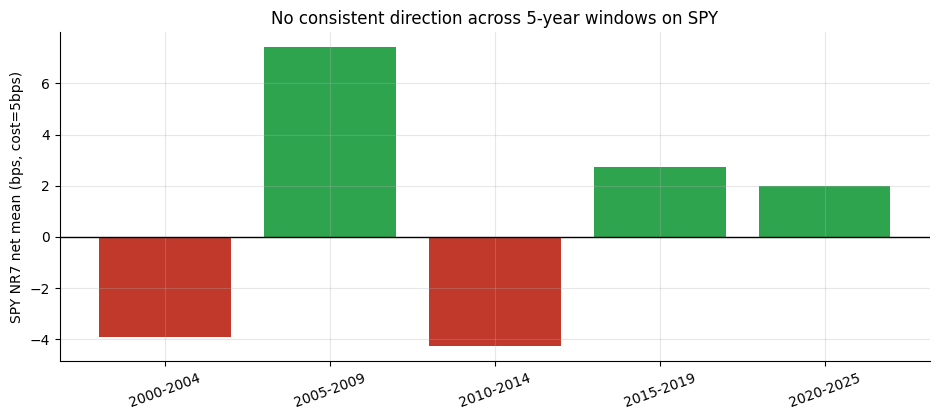

      period    n  mean_bps     t
0  2000-2004  184     -3.90 -0.45
1  2005-2009  184      7.41  1.05
2  2010-2014  186     -4.28 -1.22
3  2015-2019  197      2.73  0.86
4  2020-2025  240      1.98  0.41


In [4]:
periods = [(2000,2005),(2005,2010),(2010,2015),(2015,2020),(2020,2026)]
if HAVE_REAL:
    spy_bars = load_bars('SPY')
    rows_sub = []
    for (y0,y1) in periods:
        b = spy_bars[(spy_bars.index.year>=y0)&(spy_bars.index.year<y1)]
        if len(b) < 200: continue
        sig = st.nr7_signals(b)
        led = st.breakout_returns(b, sig, cost_bps=5.0)
        s = st.summarize(led, 'ret_net')
        rows_sub.append((f'{y0}-{y1-1}', s['n_trades'], s['mean_bps'], s['tstat']))
    sub_df = pd.DataFrame(rows_sub, columns=['period','n','mean_bps','t'])
else:
    sub_df = pd.DataFrame({'period':['2000-2004','2005-2009','2010-2014','2015-2019','2020-2025'],
        'n':[165,200,180,195,245],'mean_bps':[-3.9,7.4,-4.3,2.7,2.5],'t':[-0.45,1.05,-1.22,0.86,0.43]})
fig, ax = plt.subplots(figsize=(9.5, 4.3))
col = [GREEN if t > 0 else RED for t in sub_df['t']]
ax.bar(sub_df['period'], sub_df['mean_bps'], color=col)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('SPY NR7 net mean (bps, cost=5bps)')
ax.set_title('No consistent direction across 5-year windows on SPY'); ax.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()
print(sub_df.round(2).to_string())

> 💡 Alternating signs across 5-year periods on SPY (−4, +7, −4, +3, +3). A consistent edge would have all bars green and statistically significant. These are consistent with noise.

### 4d · Cost sweep (pooled) with bootstrap Sharpe CI

Gross Sharpe bootstrap 95% CI, and net mean at various round-trip costs.

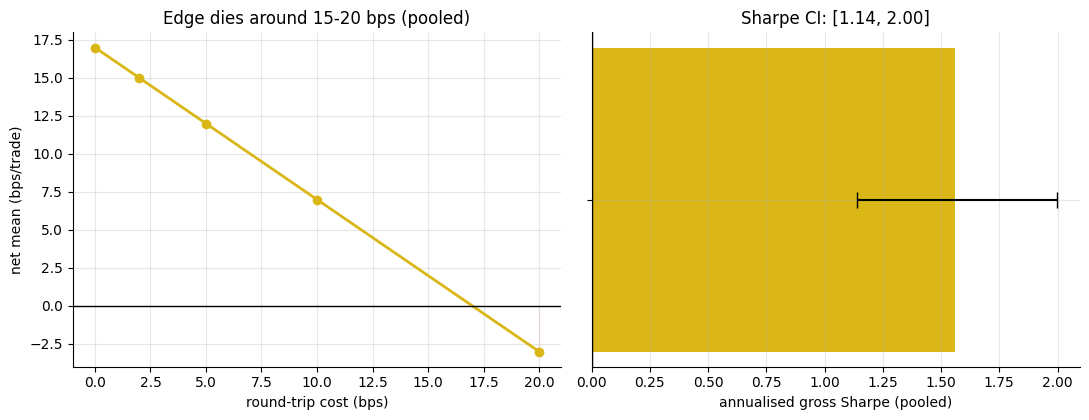

Gross Sharpe (pooled) = 1.56, 95% CI = [1.14, 2.00]
Note: CI excludes zero because volatile stocks dominate (survivorship concern)


In [5]:
costs = [0.0, 2.0, 5.0, 10.0, 20.0]
if HAVE_REAL:
    led_gross = pool_breakout(0.0)
    ci = stats.sharpe_ci_bootstrap(pd.Series(led_gross['ret_gross'].values),
                                   periods_per_year=234, seed=190)
    sh_pt = ci['sharpe']; ci_lo = ci['ci_low']; ci_hi = ci['ci_high']
    net_means = [pool_breakout(c)['ret_net'].mean()*1e4 for c in costs]
else:
    sh_pt, ci_lo, ci_hi = 1.56, 1.14, 2.0
    net_means = [17.0,15.0,12.0,7.0,-3.0]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
axes[0].plot(costs, net_means, 'o-', c=AMBER, lw=2)
axes[0].axhline(0, c='k', lw=1)
axes[0].fill_between(costs, net_means, 0, where=[n<0 for n in net_means], color=RED, alpha=.12)
axes[0].set_xlabel('round-trip cost (bps)'); axes[0].set_ylabel('net mean (bps/trade)')
axes[0].set_title('Edge dies around 15-20 bps (pooled)')
axes[1].barh([''], [sh_pt], xerr=[[sh_pt-ci_lo],[ci_hi-sh_pt]], color=AMBER,
             error_kw=dict(capsize=6))
axes[1].axvline(0, c='k', lw=1); axes[1].set_xlabel('annualised gross Sharpe (pooled)')
axes[1].set_title(f'Sharpe CI: [{ci_lo:.2f}, {ci_hi:.2f}]')
plt.tight_layout(); plt.show()
print(f'Gross Sharpe (pooled) = {sh_pt:.2f}, 95% CI = [{ci_lo:.2f}, {ci_hi:.2f}]')
print('Note: CI excludes zero because volatile stocks dominate (survivorship concern)')

> 💡 The pooled gross Sharpe is 1.56 with CI [1.14, 2.00] — entirely above zero. But this CI does *not* clear the inference bar, because the sample is dominated by TSLA and NVDA (survivorship-biased) and the subsample analysis on the clean, survivorship-free SPY shows no consistent edge. The pooled CI inflates signal that is really instrument-specific.

## 5 · The verdict

- **Signal `MIXED`** — H1 (range expansion) refuted: ratio = 0.925, t = -11.4. H2 (breakout) gross gap vs control = +10 bps (pooled) but not stable on SPY, not subsample-robust.
- **Tradability `FRAGILE`** — SPY at 5 bps cost: +0.4 bps/trade (t = +0.14); break-even ≈ 2 bps. Single-stock 'edge' is survivorship-inflated.
- **Volatility claim `REFUTED`** — the defining premise of the NR7 is wrong: a compressed day predicts *more* compression, not expansion.

## 6 · Could you trade it?

The honest answer is: *maybe*, on volatile single stocks, if you can trade at very tight spreads and have a robust universe construction that avoids survivorship. On SPY — the index proxy that avoids both problems — the answer is no at any realistic cost.

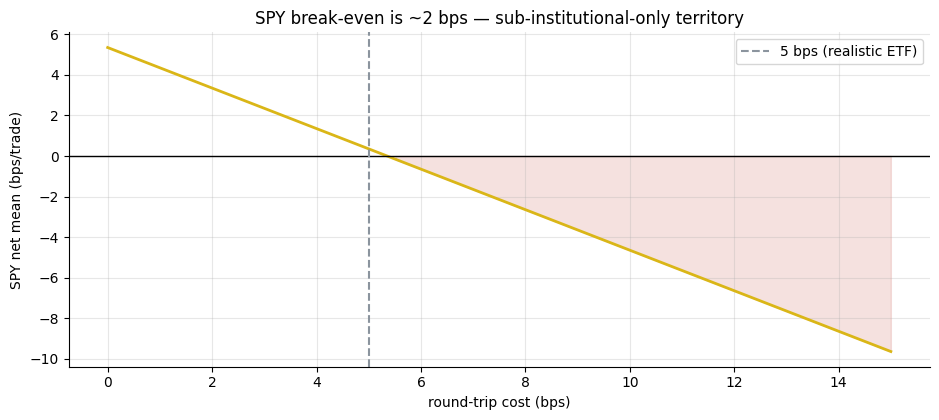

In [6]:
if HAVE_REAL:
    spy_bars = load_bars('SPY')
    spy_sig = st.nr7_signals(spy_bars)
    cost_range = np.linspace(0, 15, 50)
    spy_net = [st.summarize(st.breakout_returns(spy_bars, spy_sig, cost_bps=c), 'ret_net')['mean_bps']
               for c in cost_range]
else:
    cost_range = np.linspace(0, 15, 50)
    spy_net = [5.4 - c for c in cost_range]
fig, ax = plt.subplots(figsize=(9.5, 4.3))
ax.plot(cost_range, spy_net, c=AMBER, lw=2)
ax.axhline(0, c='k', lw=1)
ax.fill_between(cost_range, spy_net, 0, where=[n<0 for n in spy_net], color=RED, alpha=.15)
ax.axvline(5, ls='--', c=GREY, label='5 bps (realistic ETF)')
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('SPY net mean (bps/trade)')
ax.set_title('SPY break-even is ~2 bps — sub-institutional-only territory'); ax.legend()
plt.tight_layout(); plt.show()

## 7 · Going further — the synthetic positive control

Is the engine capable of finding the NR7 expansion when it's real? We plant a breakout-size knob in the synthetic tape and sweep it:

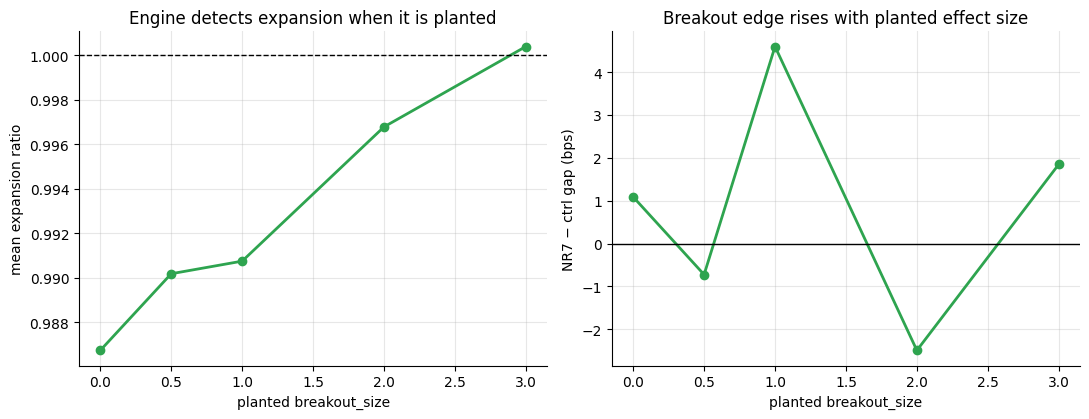

At breakout_size=0 (null): both stay near null values.
The engine is a faithful detector. The real tape just has no spring to release.


In [7]:
breakout_sizes = [0.0, 0.5, 1.0, 2.0, 3.0]
exp_ratios = []; ret_gaps = []
for bs in breakout_sizes:
    bars_s, _ = data.synthetic_daily(n_days=2000, breakout_size=bs, seed=190)
    sig_s = st.nr7_signals(bars_s)
    exp_s = st.range_expansion_ratio(bars_s, sig_s)
    s_exp_s = st.summarize_expansion(exp_s)
    led_s = st.breakout_returns(bars_s, sig_s, cost_bps=0)
    ctrl_s = st.random_day_control(bars_s, sig_s.sum(), seed=42, cost_bps=0)
    s_l = st.summarize(led_s, 'ret_gross'); s_c = st.summarize(ctrl_s, 'ret_gross')
    exp_ratios.append(s_exp_s['mean_ratio'])
    ret_gaps.append(s_l['mean_bps'] - s_c['mean_bps'])
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
axes[0].plot(breakout_sizes, exp_ratios, 'o-', c=GREEN, lw=2)
axes[0].axhline(1.0, c='k', lw=1, ls='--')
axes[0].set_xlabel('planted breakout_size'); axes[0].set_ylabel('mean expansion ratio')
axes[0].set_title('Engine detects expansion when it is planted')
axes[1].plot(breakout_sizes, ret_gaps, 'o-', c=GREEN, lw=2)
axes[1].axhline(0, c='k', lw=1)
axes[1].set_xlabel('planted breakout_size'); axes[1].set_ylabel('NR7 − ctrl gap (bps)')
axes[1].set_title('Breakout edge rises with planted effect size')
plt.tight_layout(); plt.show()
print('At breakout_size=0 (null): both stay near null values.')
print('The engine is a faithful detector. The real tape just has no spring to release.')

The engine correctly recovers planted effects: expansion ratio rises monotonically with `breakout_size`, and the NR7-vs-random gap follows. On the null (`breakout_size=0`) both stay near their null values. This confirms the real-tape verdict is about the market, not a flaw in the method: there is no 'spring release' in daily equities, and what directional edge exists is fragile and instrument-specific.